<a href="https://colab.research.google.com/github/praveenkumarrlgmp-source/meachin-learing-project/blob/main/SARSA%20Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Created a dummy 'sarsa_data.csv' for demonstration.
              SARSA DATASET
   state  action  next_state  reward
0      0       0           1      -1
1      0       1           0      -5
2      1       0           2      -1
3      1       1           1      -5
4      2       0           3      -1
5      2       1           2      -5
6      3       0           4      -1
7      3       1           3      -5
8      4       0           5      10
9      4       1           4      -5

              SARSA PARAMETERS
Alpha (α)   : 0.8
Beta (β)    : 0.01
Gamma (γ)   : 0.95
Epsilon (ε) : 0.01
Episodes    : 1000

                  SARSA Q-TABLE

State		Left		Right
0		4.44		-0.79
1		5.72		0.42
2		7.07		1.72
3		8.50		3.07
4		10.00		4.50
5		0.00		0.00

                    BEST PATH
0 -> 1 -> 2 -> 3 -> 4 -> 5


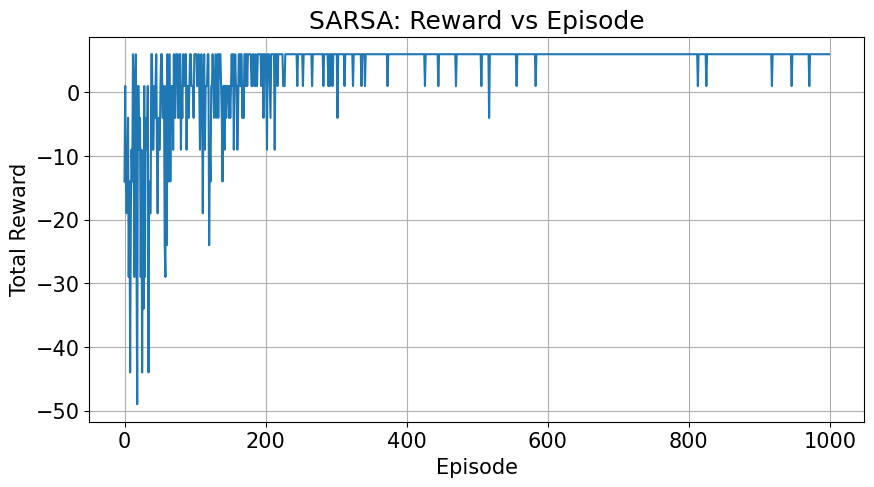

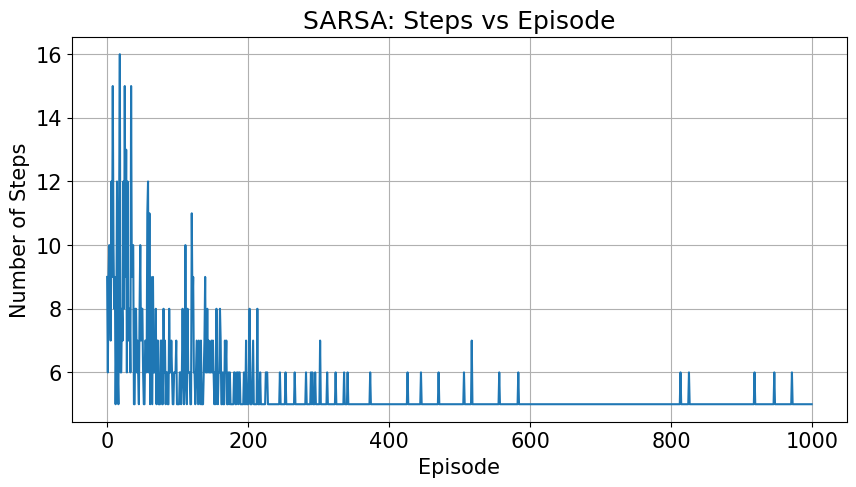

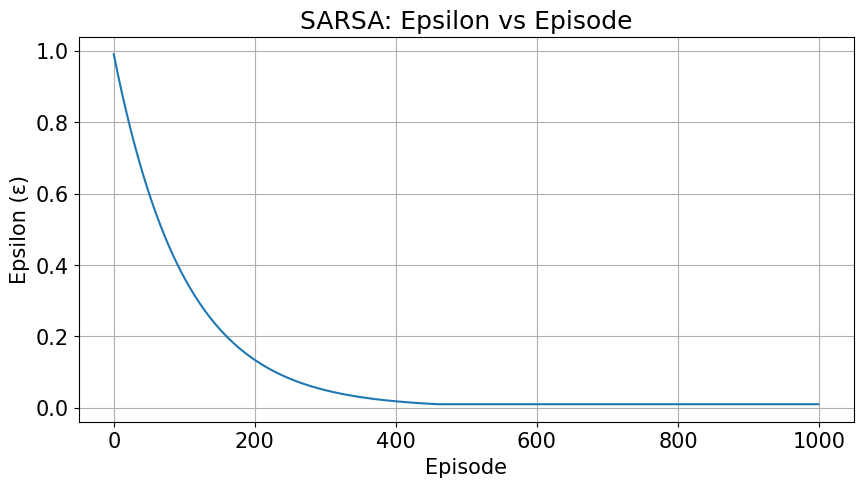

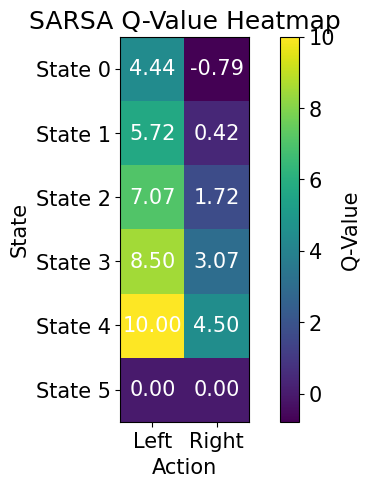


             SARSA TRAINING COMPLETED
Starting State : 0
Goal State     : 5
Best Path      : [0, 1, 2, 3, 4, 5]
Final Epsilon  : 0.01


In [7]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt

# ============================================================
# 1. LOAD CSV DATASET
# ============================================================

file_name = "sarsa_data.csv"

# Create a dummy sarsa_data.csv if it doesn't exist
# This ensures the code runs without FileNotFoundError
try:
    with open(file_name, 'x') as f:
        f.write("state,action,next_state,reward\n")
        f.write("0,0,1,-1\n")
        f.write("0,1,0,-5\n")
        f.write("1,0,2,-1\n")
        f.write("1,1,1,-5\n")
        f.write("2,0,3,-1\n")
        f.write("2,1,2,-5\n")
        f.write("3,0,4,-1\n")
        f.write("3,1,3,-5\n")
        f.write("4,0,5,10\n")
        f.write("4,1,4,-5\n")
    print(f"Created a dummy '{file_name}' for demonstration.")
except FileExistsError:
    print(f"'{file_name}' already exists. Using existing file.")

data = pd.read_csv(file_name)

print("=" * 60)
print("              SARSA DATASET")
print("=" * 60)

print(data)

# ============================================================
# 2. GET STATES AND ACTIONS
# ============================================================

states = sorted(data["state"].unique())

num_states = max(
    data["state"].max(),
    data["next_state"].max()
) + 1

actions = sorted(data["action"].unique())

num_actions = len(actions)

goal_state = data["next_state"].max()


# ============================================================
# 3. PARAMETERS
# ============================================================

alpha = 0.8       # α - Learning Rate
gamma = 0.95      # γ - Discount Factor
epsilon = 1.0     # ε - Exploration Rate
beta = 0.01       # β - Exploration Decay

min_epsilon = 0.01

episodes = 1000


# ============================================================
# 4. CREATE Q-TABLE
# ============================================================

Q = np.zeros((num_states, num_actions))


# ============================================================
# 5. STORE RESULTS
# ============================================================

episode_rewards = []
episode_steps = []
epsilon_values = []


# ============================================================
# 6. GET NEXT STATE AND REWARD FROM CSV
# ============================================================

def get_next_state(state, action):

    row = data[
        (data["state"] == state) &
        (data["action"] == action)
    ]

    if row.empty:
        return state, -1

    next_state = int(row.iloc[0]["next_state"])
    reward = float(row.iloc[0]["reward"])

    return next_state, reward


# ============================================================
# 7. EPSILON-GREEDY POLICY
# ============================================================

def choose_action(state, epsilon):

    # Exploration
    if random.random() < epsilon:

        return random.choice(actions)

    # Exploitation
    else:

        return int(np.argmax(Q[state]))


# ============================================================
# 8. SARSA TRAINING
# ============================================================

for episode in range(episodes):

    # Start state
    state = 0

    # Select first action
    action = choose_action(
        state,
        epsilon
    )

    total_reward = 0
    steps = 0


    while state != goal_state:

        # ----------------------------------------------------
        # Take action using CSV
        # ----------------------------------------------------

        next_state, reward = get_next_state(
            state,
            action
        )


        # ----------------------------------------------------
        # Select next action
        # ----------------------------------------------------

        if next_state != goal_state:

            next_action = choose_action(
                next_state,
                epsilon
            )

        else:

            next_action = 0


        # ----------------------------------------------------
        # SARSA UPDATE
        # ----------------------------------------------------

        current_q = Q[state, action]

        if next_state == goal_state:

            target = reward

        else:

            target = reward + (
                gamma *
                Q[next_state, next_action]
            )


        Q[state, action] = current_q + alpha * (
            target - current_q
        )


        # ----------------------------------------------------
        # Move to next state
        # ----------------------------------------------------

        state = next_state
        action = next_action

        total_reward += reward
        steps += 1


        # Safety limit
        if steps >= 100:

            break


    # ========================================================
    # BETA - EPSILON DECAY
    # ========================================================

    epsilon = max(
        min_epsilon,
        epsilon * np.exp(-beta)
    )


    # Save results
    episode_rewards.append(total_reward)
    episode_steps.append(steps)
    epsilon_values.append(epsilon)


# ============================================================
# 9. DISPLAY PARAMETERS
# ============================================================

print("\n" + "=" * 60)
print("              SARSA PARAMETERS")
print("=" * 60)

print("Alpha (α)   :", alpha)
print("Beta (β)    :", beta)
print("Gamma (γ)   :", gamma)
print("Epsilon (ε) :", epsilon)
print("Episodes    :", episodes)


# ============================================================
# 10. DISPLAY Q-TABLE
# ============================================================

print("\n" + "=" * 60)
print("                  SARSA Q-TABLE")
print("=" * 60)

print("\nState\t\tLeft\t\tRight")

for state in range(num_states):

    print(
        f"{state}\t\t"
        f"{Q[state, 0]:.2f}\t\t"
        f"{Q[state, 1]:.2f}"
    )


# ============================================================
# 11. FIND BEST PATH
# ============================================================

state = 0

path = [state]

visited = set()

while state != goal_state:

    # Prevent infinite loop
    if state in visited:

        break

    visited.add(state)

    action = np.argmax(Q[state])

    next_state, reward = get_next_state(
        state,
        action
    )

    state = next_state

    path.append(state)


# ============================================================
# 12. DISPLAY BEST PATH
# ============================================================

print("\n" + "=" * 60)
print("                    BEST PATH")
print("=" * 60)

print(
    " -> ".join(
        map(str, path)
    )
)


# ============================================================
# 13. GRAPH - REWARD VS EPISODE
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    episode_rewards
)

plt.title(
    "SARSA: Reward vs Episode"
)

plt.xlabel(
    "Episode"
)

plt.ylabel(
    "Total Reward"
)

plt.grid(True)

plt.show()


# ============================================================
# 14. GRAPH - STEPS VS EPISODE
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    episode_steps
)

plt.title(
    "SARSA: Steps vs Episode"
)

plt.xlabel(
    "Episode"
)

plt.ylabel(
    "Number of Steps"
)

plt.grid(True)

plt.show()


# ============================================================
# 15. GRAPH - EPSILON VS EPISODE
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    epsilon_values
)

plt.title(
    "SARSA: Epsilon vs Episode"
)

plt.xlabel(
    "Episode"
)

plt.ylabel(
    "Epsilon (ε)"
)

plt.grid(True)

plt.show()


# ============================================================
# 16. Q-TABLE HEATMAP
# ============================================================

plt.figure(figsize=(8, 5))

plt.imshow(
    Q,
    cmap="viridis"
)

plt.colorbar(
    label="Q-Value"
)

plt.xticks(
    range(num_actions),
    ["Left", "Right"]
)

plt.yticks(
    range(num_states),
    [f"State {i}" for i in range(num_states)]
)

plt.xlabel(
    "Action"
)

plt.ylabel(
    "State"
)

plt.title(
    "SARSA Q-Value Heatmap"
)


# Display Q-values
for i in range(num_states):

    for j in range(num_actions):

        plt.text(
            j,
            i,
            f"{Q[i, j]:.2f}",
            ha="center",
            va="center",
            color="white"
        )

plt.show()


# ============================================================
# 17. FINAL RESULT
# ============================================================

print("\n" + "=" * 60)
print("             SARSA TRAINING COMPLETED")
print("=" * 60)

print("Starting State :", 0)

print("Goal State     :", goal_state)

print("Best Path      :", path)

print(
    "Final Epsilon  :",
    round(epsilon, 4)
)